In [64]:
import stim
import pymatching
import numpy as np
import scipy
import matplotlib.pyplot as plt

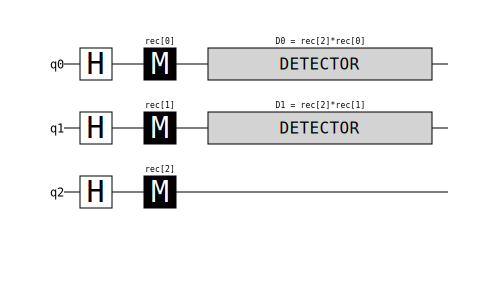

In [65]:
circuit = stim.Circuit()
circuit.append("H", [0])
circuit.append("H", [1])
circuit.append("H", [2])
circuit.append("M", [0, 1, 2])
circuit.append("DETECTOR", [stim.target_rec(-1), stim.target_rec(-3)])
circuit.append("DETECTOR", [stim.target_rec(-1), stim.target_rec(-2)])

circuit.diagram('timeline-svg')

In [66]:
sampler = circuit.compile_detector_sampler()
data_array = sampler.sample(shots=10000)
counter = 0

for i in range(10000):
    if data_array[i][0]*data_array[i][1] == True:
        counter +=1

print(counter/10000)


0.2544


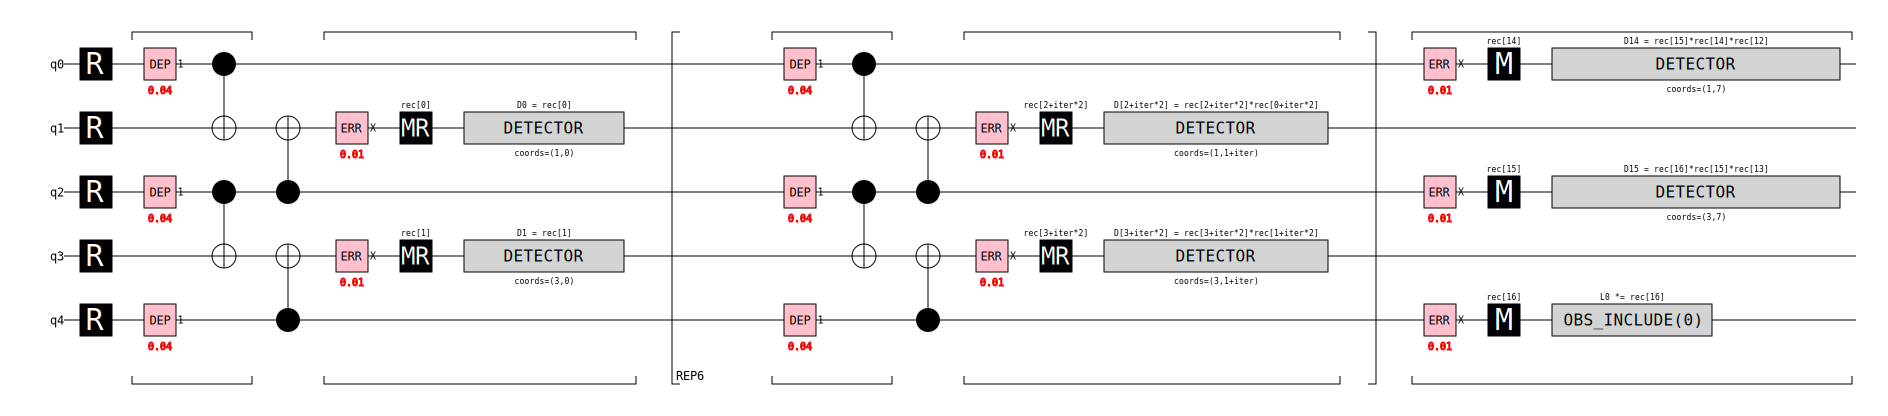

In [67]:
circuit = stim.Circuit.generated(
    "repetition_code:memory",
    distance=3,
    rounds=7,
    before_round_data_depolarization=0.04,
    before_measure_flip_probability=0.01,
)

circuit.diagram('timeline-svg')

In [68]:
sampler = circuit.compile_sampler()
one_sample = sampler.sample(shots=1)[0]
for k in range(0, len(one_sample),8):
    timeslice = one_sample[k:k+8]
    print("".join("1" if e else "_" for e in timeslice))

________
________
_


In [69]:
detector_sampler = circuit.compile_detector_sampler()
one_sample = detector_sampler.sample(shots=1)[0]
for k in range(0, len(one_sample), 8):
    timeslice = one_sample[k:k+8]
    print("".join("!" if e else "_" for e in timeslice))

________
________


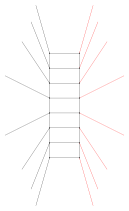

In [70]:
dem = circuit.detector_error_model()
dem.diagram('matchgraph-svg')

In [ ]:
def count_logical_errors(circuit: stim.Circuit, num_shots: int) -> int:
    # Sample the circuit.
    sampler = circuit.compile_detector_sampler()
    detection_events, observable_flips = sampler.sample(num_shots, separate_observables=True)

    # Configure a decoder using the circuit.
    detector_error_model = circuit.detector_error_model(decompose_errors=True)
    matcher = pymatching.Matching.from_detector_error_model(detector_error_model)

    # Run the decoder.
    predictions = matcher.decode_batch(detection_events)

    # Count the mistakes.
    num_errors = 0
    for shot in range(num_shots):
        actual_for_shot = observable_flips[shot]
        predicted_for_shot = predictions[shot]
        if not np.array_equal(actual_for_shot, predicted_for_shot):
            num_errors += 1
    return num_errors

import matplotlib.pyplot as plt

num_shots = 10000
for d in [3, 5, 7]:
    xs = []
    ys = []
    for noise in np.linspace(0.01, 0.3, 20):
        circuit = stim.Circuit.generated(
            "repetition_code:memory",
            rounds=1,
            distance=d,
            before_round_data_depolarization=noise)
        circuit = stim.Circuit(str(circuit).replace(
            f"DEPOLARIZE1({noise})",
            f"X_ERROR({noise})"
            ))
        
        num_errors_sampled = count_logical_errors(circuit, num_shots)
        xs.append(noise)
        ys.append(num_errors_sampled / num_shots)
    plt.plot(xs, ys, label="d=" + str(d))

plt.xlabel("physical error rate")
plt.ylabel("logical error rate per shot")
plt.legend()
plt.show()

In [72]:
circuit = stim.Circuit.generated(
    "repetition_code:memory",
    rounds=100,
    distance=9,
    before_round_data_depolarization=0.2,
    before_measure_flip_probability=0.01)
num_shots = 10000
num_logical_errors = count_logical_errors(circuit, num_shots)
print("there were", num_logical_errors, "wrong predictions (logical errors) out of", num_shots, "shots")

there were 3840 wrong predictions (logical errors) out of 10000 shots


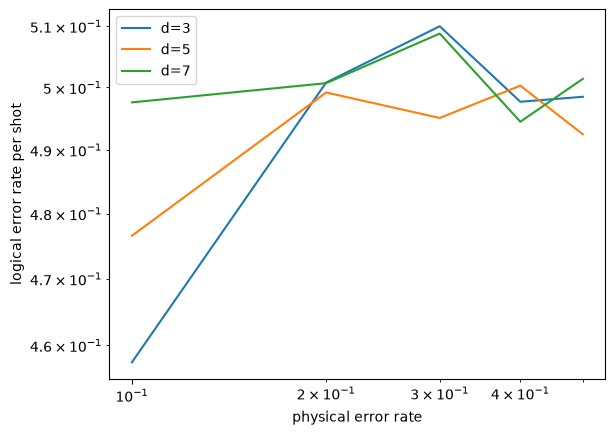

In [84]:
import matplotlib.pyplot as plt
num_shots = 10000
for d in [3, 5, 7]:
    xs = []
    ys = []
    for noise in [0.1, 0.2, 0.3, 0.4, 0.5]:
        circuit = stim.Circuit.generated(
            "repetition_code:memory",
            rounds=d * 3,
            distance=d,
            after_clifford_depolarization=noise,
            after_reset_flip_probability=noise,
            before_measure_flip_probability=noise,
            before_round_data_depolarization=noise)
        num_errors_sampled = count_logical_errors(circuit, num_shots)
        xs.append(noise)
        ys.append(num_errors_sampled / num_shots)
    plt.plot(xs, ys, label="d=" + str(d))
plt.loglog()
plt.xlabel("physical error rate")
plt.ylabel("logical error rate per shot")
plt.legend()
plt.show()

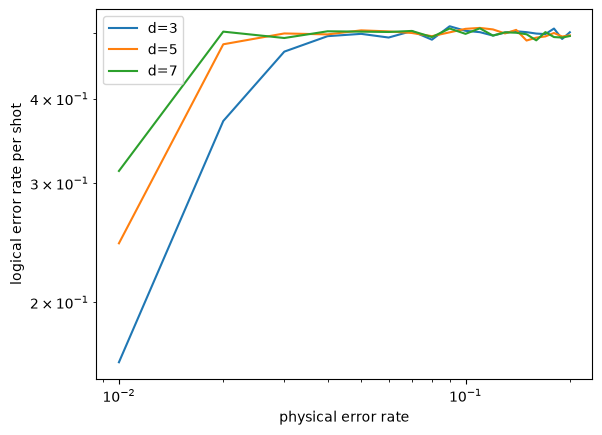

In [86]:
import matplotlib.pyplot as plt
num_shots = 10000
for d in [3, 5, 7]:
    xs = []
    ys = []
    for noise in np.linspace(0.01, 0.2, 20):
        circuit = stim.Circuit.generated(
        "surface_code:rotated_memory_x",
        distance=d,
        rounds=d*3,
        after_clifford_depolarization=noise,
        after_reset_flip_probability=noise,
        before_measure_flip_probability=noise,
        before_round_data_depolarization=noise,
)
        num_errors_sampled = count_logical_errors(circuit, num_shots)
        xs.append(noise)
        ys.append(num_errors_sampled / num_shots)
    plt.plot(xs, ys, label="d=" + str(d))
plt.loglog()
plt.xlabel("physical error rate")
plt.ylabel("logical error rate per shot")
plt.legend()
plt.show()